In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

import scvi
scvi.settings.seed = 0

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0


In [11]:
results_folder = '../intermediate_data/cell2location_res/'
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/pbmc_signatures'
run_name = f'{results_folder}/cell2location_map'

In [3]:
pbmc = sc.read_h5ad('../intermediate_data/processed_sces/pbmc8k.h5ad')

In [4]:
for col in ['cell_type', 'Sample']:
    print(f"\n{col}:")
    print(pbmc.obs[col].unique().tolist())


cell_type:
['B cells', 'Monocytes', 'T cells', 'NK cells', 'Dendritic cells', 'Progenitors']

Sample:
['pbmc8k']


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


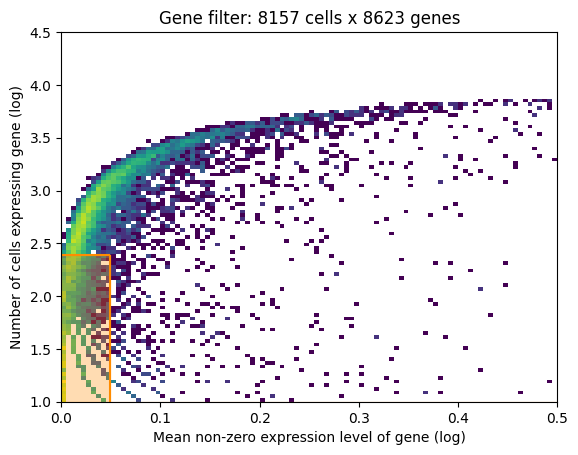

In [5]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(pbmc, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
pbmc = pbmc[:, selected].copy()

In [6]:
cell2location.models.RegressionModel.setup_anndata(adata=pbmc,labels_key='cell',batch_key='Sample')

In [7]:
# create the regression model
from cell2location.models import RegressionModel
pbmc_mod = RegressionModel(pbmc)

# view anndata_setup as a sanity check
pbmc_mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'cell',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 8157  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   6   │
│          n_vars          │ 8623  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │   pbmc8k   │          0          │
└─────────────────────┴────────────┴─────────────────────┘

                    labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location  ┃   Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell'] │     B cells     │          0          │
│                   │ Dendritic cells │          1          │
│                   │    Monocytes    │          2          │
│                   │    NK cells     │          3          │
│                   │   Progenitors   │          4          │
│                   │     T cells     │          5          │
└───────────────────┴─────────────────┴─────────────────────┘

In [8]:
pbmc_mod.train(max_epochs=1500,lr=0.005)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 1500/1500: 100%|███████████████████████████| 1500/1500 [3:16:02<00:00,  5.51s/it, v_num=1, elbo_train=3.31e+7]

`Trainer.fit` stopped: `max_epochs=1500` reached.


Epoch 1500/1500: 100%|███████████████████████████| 1500/1500 [3:16:02<00:00,  7.84s/it, v_num=1, elbo_train=3.31e+7]


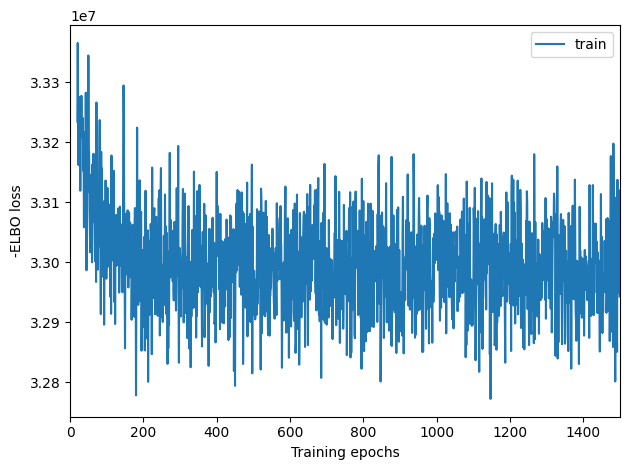

In [9]:
pbmc_mod.plot_history(20)

In [13]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
pbmc = pbmc_mod.export_posterior(
    pbmc, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

# Save model
pbmc_mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
pbmc_file = f"{ref_run_name}/pbmc_cell2location_model.h5ad"
pbmc.write(pbmc_file)
pbmc_file

Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [02:44<00:00,  6.07it/s]


'../intermediate_data/cell2location_res//pbmc_signatures/pbmc_cell2location_model.h5ad'

In [14]:
pbmc = pbmc_mod.export_posterior(
    pbmc, 
    #use_quantiles=True,
    # choose quantiles
    #add_to_obsm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 2500}
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [02:35<00:00,  6.43it/s]


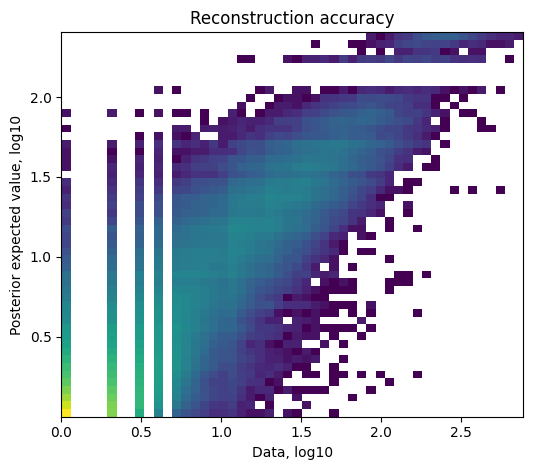

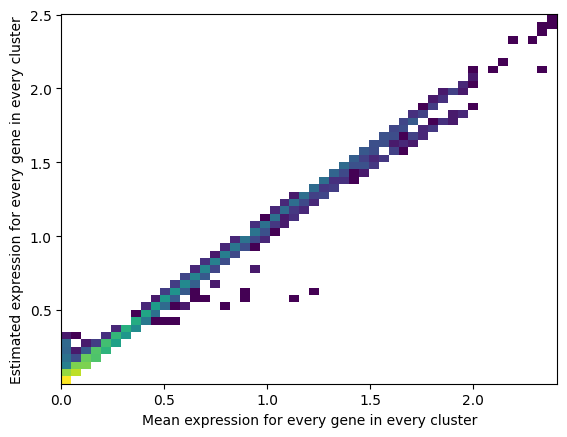

In [15]:
pbmc_mod.plot_QC()

In [16]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in pbmc.varm.keys():
    inf_aver = pbmc.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in pbmc.uns['mod']['factor_names']]].copy()
else:
    inf_aver = pbmc.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in pbmc.uns['mod']['factor_names']]].copy()
inf_aver.columns = pbmc.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B cells,Dendritic cells,Monocytes,NK cells,Progenitors
FAM41C,0.062135,0.104425,0.041486,0.056972,0.136323
NOC2L,0.193364,0.492408,0.160757,0.279163,0.538057
HES4,0.011904,0.100523,0.332471,0.017244,0.111004
ISG15,0.342497,0.846904,0.976588,0.656156,0.299126
TNFRSF18,0.018016,0.027707,0.011758,0.234092,0.089965


Ovarian Cancer Signature

In [17]:
results_folder = '../intermediate_data/cell2location_res/'
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/ovarian_cancer_signature'

In [18]:
ovarian_cancer = sc.read_h5ad('../Data/ovarian_cancer_scRNAseq/921d46a3-69b4-44a8-b2d6-9ef5c7803bc3.h5ad')
ovarian_cancer_mask = ovarian_cancer.obs['assay'].str.startswith('10x') & (ovarian_cancer.obs['disease'] == 'ovarian cancer')
ovarian_cancer_sub = ovarian_cancer[ovarian_cancer_mask].copy()

for col in ['assay', 'cell_type', 'disease']:
    print(f"\n{col}:")
    print(ovarian_cancer_sub.obs[col].unique().tolist())


assay:
["10x 3' v2"]

cell_type:
['mononuclear phagocyte', 'malignant cell', 'fibroblast', 'T cell', 'endothelial cell', 'plasmacytoid dendritic cell', 'B cell', 'epithelial cell', 'mast cell']

disease:
['ovarian cancer']


In [19]:
ovarian_cancer_sub.obs['cell_type'].value_counts()

cell_type
T cell                         8465
malignant cell                 7684
fibroblast                     7610
mononuclear phagocyte          5252
B cell                         1903
endothelial cell                978
epithelial cell                 978
plasmacytoid dendritic cell     150
mast cell                        45
Name: count, dtype: int64

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


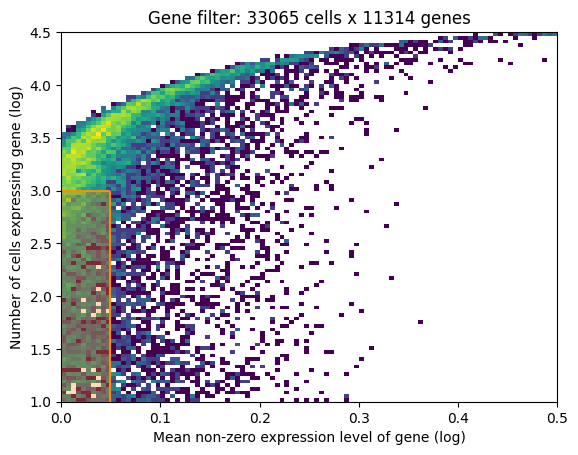

In [20]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(ovarian_cancer_sub, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
ovarian_cancer_sub = ovarian_cancer_sub[:, selected].copy()

In [21]:
# Setting the raw counts to the adata object
print(ovarian_cancer_sub.raw)
ovarian_cancer_sub = ovarian_cancer_sub.raw.to_adata()

# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=ovarian_cancer_sub,labels_key='cell_type',batch_key='batch')

from cell2location.models import RegressionModel
ovarian_mod = RegressionModel(ovarian_cancer_sub)

# view anndata_setup as a sanity check
ovarian_mod.view_anndata_setup()

Raw AnnData with n_obs × n_vars = 33065 × 44649
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'


Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'batch',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 33065 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   9   │
│          n_vars          │ 44649 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['batch'] │     2      │          0          │
└────────────────────┴────────────┴─────────────────────┘

                            labels State Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃         Categories          ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │         fibroblast          │          0          │
│                        │       epithelial cell       │          1          │
│                        │           T cell            │          2          │
│                        │          mast cell          │          3          │
│                        │    mononuclear phagocyte    │          4          │
│                        │      endothelial cell       │          5          │
│                        │           B cell            │          6          │
│                        │ plasmacytoid dendritic cell │          7          │
│                        │       malignant cell        │          8          │
└────────────────────────┴─────────────────────────────┴─────────────────────┘

In [22]:
ovarian_mod.train(max_epochs=1000)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 1000/1000: 100%|██████████████████████████| 1000/1000 [26:37:03<00:00, 94.20s/it, v_num=1, elbo_train=1.74e+8]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|██████████████████████████| 1000/1000 [26:37:03<00:00, 95.82s/it, v_num=1, elbo_train=1.74e+8]


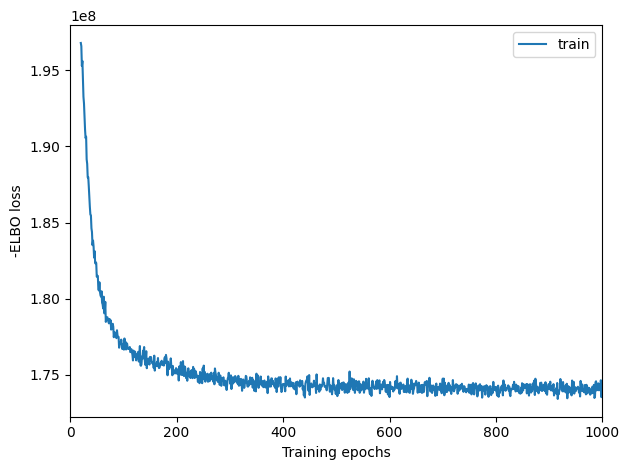

In [24]:
ovarian_mod.plot_history(20)

In [25]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
ovarian_cancer_sub = ovarian_mod.export_posterior(
    ovarian_cancer_sub, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

# Save model
ovarian_mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
ovarian_file = f"{ref_run_name}/ovarian_cancer_cell2location_model.h5ad"
ovarian_cancer_sub.write(ovarian_file)
ovarian_file

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [13:36<00:00,  1.22it/s]


'../intermediate_data/cell2location_res//ovarian_cancer_signature/ovarian_cancer_cell2location_model.h5ad'

In [26]:
ovarian_cancer_sub = ovarian_mod.export_posterior(
    ovarian_cancer_sub, 
    #use_quantiles=True,
    # choose quantiles
    #add_to_obsm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 2500}
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [13:14<00:00,  1.26it/s]


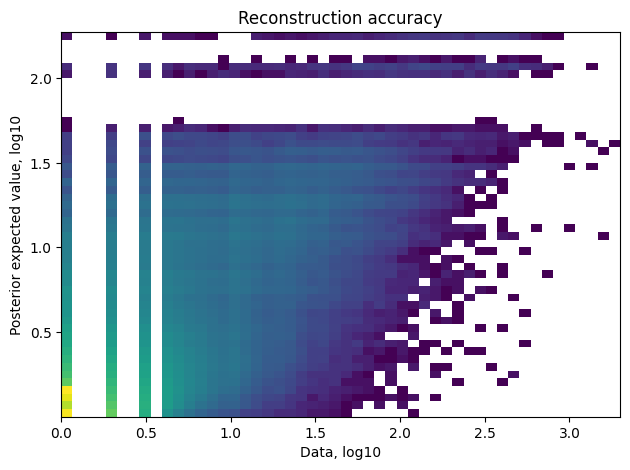

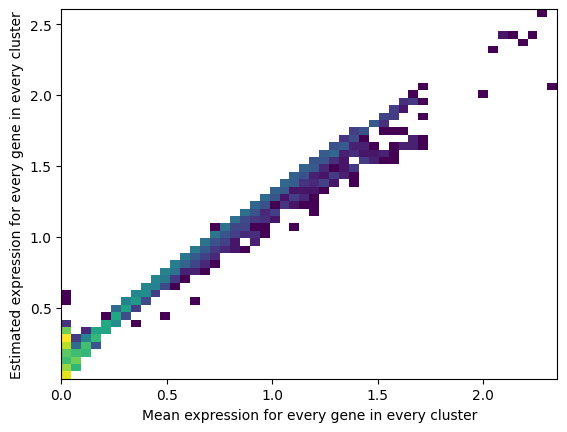

In [27]:
ovarian_mod.plot_QC()

In [28]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in ovarian_cancer_sub.varm.keys():
    inf_aver = ovarian_cancer_sub.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in ovarian_cancer_sub.uns['mod']['factor_names']]].copy()
else:
    inf_aver = ovarian_cancer_sub.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in ovarian_cancer_sub.uns['mod']['factor_names']]].copy()
inf_aver.columns = ovarian_cancer_sub.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,fibroblast,epithelial cell,T cell,mast cell,mononuclear phagocyte
ENSG00000000003,0.298490,0.273180,0.312493,0.661944,0.389004
ENSG00000000005,0.008814,0.425197,0.004532,0.972341,0.011738
ENSG00000000419,0.508813,0.639294,0.659684,1.137802,0.715172
ENSG00000000457,0.031187,0.035353,0.029076,0.092243,0.036036
ENSG00000000460,0.043788,0.053373,0.052404,0.538570,0.056520


In [29]:
ovarian_cancer_sub.var

,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000000003,TSPAN6,NCBITaxon:9606,gene,2396,protein_coding
ENSG00000000005,TNMD,NCBITaxon:9606,gene,873,protein_coding
ENSG00000000419,DPM1,NCBITaxon:9606,gene,1262,protein_coding
ENSG00000000457,SCYL3,NCBITaxon:9606,gene,2916,protein_coding
ENSG00000000460,FIRRM,NCBITaxon:9606,gene,2661,protein_coding
...,...,...,...,...,...
ENSG00000288596,C8orf44,NCBITaxon:9606,gene,665,lncRNA
ENSG00000288602,C8orf44-SGK3,NCBITaxon:9606,gene,1788,protein_coding
ENSG00000288603,SNORA74C-2,NCBITaxon:9606,gene,201,snoRNA
ENSG00000288686,ENSG00000288686,NCBITaxon:9606,gene,106,transcribed_unprocessed_pseudogene


Bone Marrow Signature

In [2]:
results_folder = '../intermediate_data/cell2location_res/'
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/bone_marrow_signature'

In [3]:
aml = sc.read_h5ad('../intermediate_data/processed_sces/AML0210X.h5ad')

In [5]:
for col in ['cell_type', 'Sample']:
    print(f"\n{col}:")
    print(aml.obs[col].unique().tolist())


cell_type:
['T cells', 'Progenitors', 'B cells', 'Dendritic cells', 'NK cells', 'Monocytes']

Sample:
['./GSM4664010_3958']


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


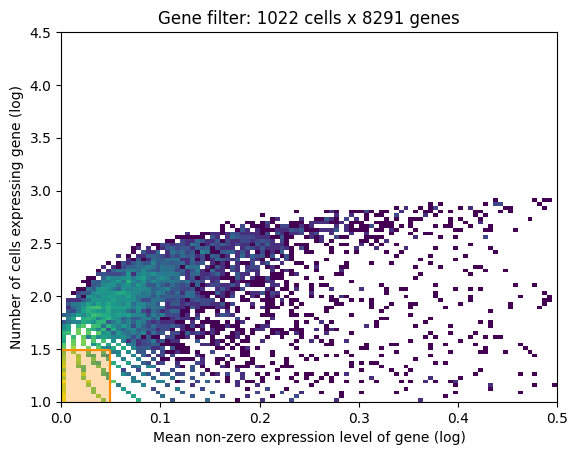

In [6]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(aml, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
aml = aml[:, selected].copy()

In [7]:
cell2location.models.RegressionModel.setup_anndata(adata=aml,labels_key='cell',batch_key='Sample')

In [8]:
# create the regression model
from cell2location.models import RegressionModel
aml_mod = RegressionModel(aml)

# view anndata_setup as a sanity check
aml_mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'cell',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 1022  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   6   │
│          n_vars          │ 8291  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                      batch State Registry                       
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃    Categories     ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │ ./GSM4664010_3958 │          0          │
└─────────────────────┴───────────────────┴─────────────────────┘

                    labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location  ┃   Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell'] │     B cells     │          0          │
│                   │ Dendritic cells │          1          │
│                   │    Monocytes    │          2          │
│                   │    NK cells     │          3          │
│                   │   Progenitors   │          4          │
│                   │     T cells     │          5          │
└───────────────────┴─────────────────┴─────────────────────┘

In [9]:
aml_mod.train(max_epochs=3000,lr=0.005)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 3000/3000: 100%|█████████████████████████████| 3000/3000 [29:54<00:00,  1.66it/s, v_num=1, elbo_train=3.48e+6]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 3000/3000: 100%|█████████████████████████████| 3000/3000 [29:54<00:00,  1.67it/s, v_num=1, elbo_train=3.48e+6]


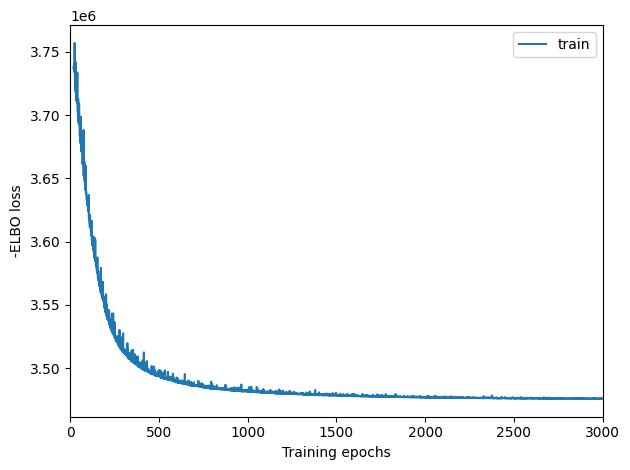

In [10]:
aml_mod.plot_history(20)

In [11]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
aml = aml_mod.export_posterior(
    aml, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

# Save model
aml_mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
aml_file = f"{ref_run_name}/bone_marrow_cell2location_model.h5ad"
aml.write(aml_file)
aml_file

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [01:10<00:00, 14.21it/s]


'../intermediate_data/cell2location_res//bone_marrow_signature/bone_marrow_cell2location_model.h5ad'

In [12]:
aml = aml_mod.export_posterior(
    aml, 
    #use_quantiles=True,
    # choose quantiles
    #add_to_obsm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 2500}
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [01:06<00:00, 14.94it/s]


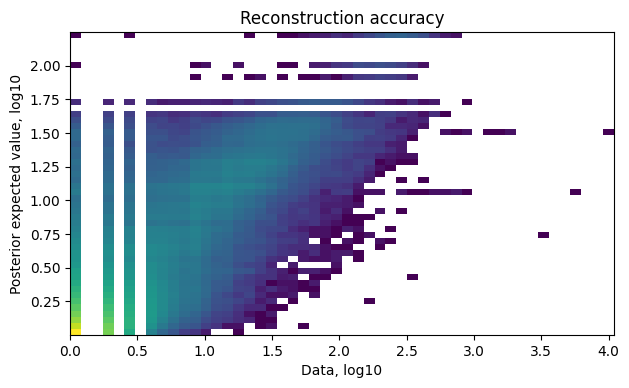

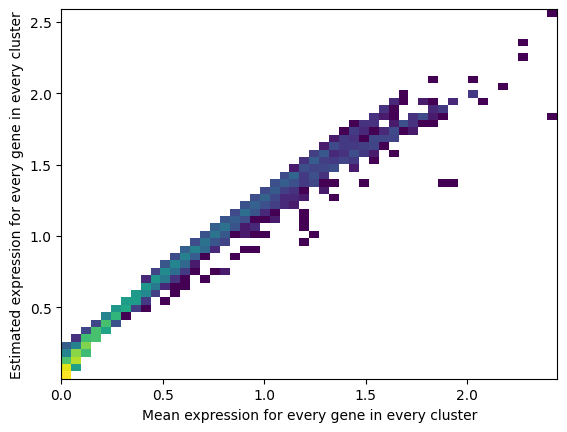

In [13]:
aml_mod.plot_QC()

In [15]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in aml.varm.keys():
    inf_aver = aml.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in aml.uns['mod']['factor_names']]].copy()
else:
    inf_aver = aml.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in aml.uns['mod']['factor_names']]].copy()
inf_aver.columns = aml.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B cells,Dendritic cells,Monocytes,NK cells,Progenitors
NOC2L,0.261802,0.977940,0.173918,0.369334,1.102544
ISG15,0.409845,0.369548,1.100994,0.893329,0.474203
C1orf159,0.053567,0.112714,0.045660,0.109386,0.242458
TNFRSF18,0.069783,0.196949,0.025270,0.190916,0.426556
TNFRSF4,0.019836,0.137139,0.025422,0.171472,0.141586


PBMC20k

In [18]:
def generate_cell2loc_signature(
    tissue_name: str,
    processed_sce_path: str,
    results_folder: str = '../intermediate_data/cell2location_res/',
    n_epochs: int = 30000,
    cell_count_cutoff: int = 5,
    cell_percentage_cutoff2: float = 0.03,
    nonz_mean_cutoff: float = 1.12,
    lr: float = 0.005,
    num_samples: int = 1000,
    batch_size: int = 2500,
) -> str:
    """
    Train a cell2location RegressionModel to generate a cell type signature.

    Parameters
    ----------
    tissue_name : str
        Name of the tissue/dataset (used for naming output files).
    processed_sce_path : str
        Path to the input .h5ad file.
    results_folder : str
        Root folder for saving model outputs.
    n_epochs : int
        Number of training epochs.
    cell_count_cutoff, cell_percentage_cutoff2, nonz_mean_cutoff : float
        Gene filtering thresholds passed to filter_genes().
    lr : float
        Learning rate for training.
    num_samples, batch_size : int
        Posterior export parameters.

    Returns
    -------
    str
        Path to the saved .h5ad file with model results.
    """
    import scanpy as sc
    import cell2location
    from cell2location.utils.filtering import filter_genes
    from cell2location.models import RegressionModel

    # Paths
    ref_run_name = f'{results_folder}/{tissue_name}_signature'

    # Load data
    adata = sc.read_h5ad(processed_sce_path)

    # Sanity check
    for col in ['cell_type', 'Sample']:
        print(f"\n{col}:")
        print(adata.obs[col].unique().tolist())

    # Filter genes
    selected = filter_genes(
        adata,
        cell_count_cutoff=cell_count_cutoff,
        cell_percentage_cutoff2=cell_percentage_cutoff2,
        nonz_mean_cutoff=nonz_mean_cutoff,
    )
    adata = adata[:, selected].copy()

    # Setup and train model
    RegressionModel.setup_anndata(adata=adata, labels_key='cell', batch_key='Sample')
    adata_mod = RegressionModel(adata)
    adata_mod.view_anndata_setup()
    adata_mod.train(max_epochs=n_epochs, lr=lr)
    adata_mod.plot_history(20)

    # Export posterior
    adata = adata_mod.export_posterior(
        adata,
        sample_kwargs={'num_samples': num_samples, 'batch_size': batch_size},
    )

    # Save model and anndata
    adata_mod.save(ref_run_name, overwrite=True)
    adata_file = f'{ref_run_name}/{tissue_name}_cell2location_model.h5ad'
    adata.write(adata_file)

    return adata_file


cell_type:
['T cells', 'Dendritic cells', 'Monocytes', 'NK cells', 'B cells', 'Progenitors', 'Neutrophils']

Sample:
['Donor1', 'Donor2', 'Donor3', 'Donor4']


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


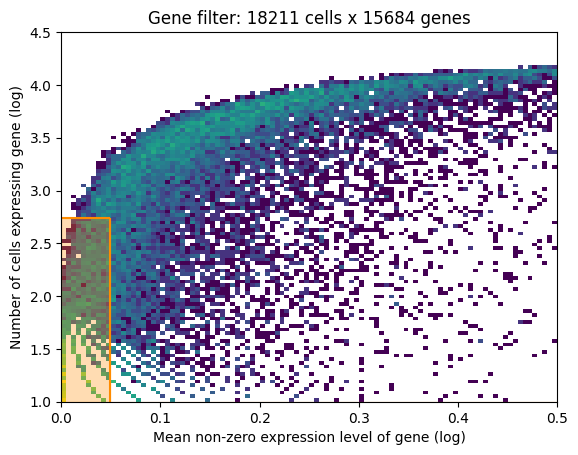

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'cell',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   4   │
│         n_cells          │ 18211 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   7   │
│          n_vars          │ 15684 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

...

Epoch 3000/3000: 100%|██████████████████████████| 3000/3000 [16:27:00<00:00, 19.41s/it, v_num=1, elbo_train=1.96e+8]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 3000/3000: 100%|██████████████████████████| 3000/3000 [16:27:00<00:00, 19.74s/it, v_num=1, elbo_train=1.96e+8]

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...



Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [04:17<00:00,  3.88it/s]


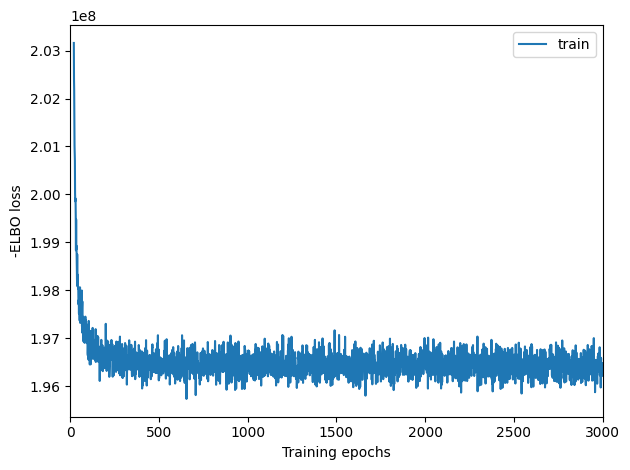

In [19]:
adata_file = generate_cell2loc_signature(
    tissue_name="PBMC20k",
    processed_sce_path='../intermediate_data/processed_sces/sequencing_depth/PBMC20k_1_cell_ranger.h5ad',
    results_folder='../intermediate_data/cell2location_res/',
    n_epochs=3000,
)


cell_type:
['NK cells', 'T cells', 'Monocytes', 'B cells', 'Dendritic cells', 'Progenitors', 'Neutrophils', 'Basophils']

Sample:
['Donor1']


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


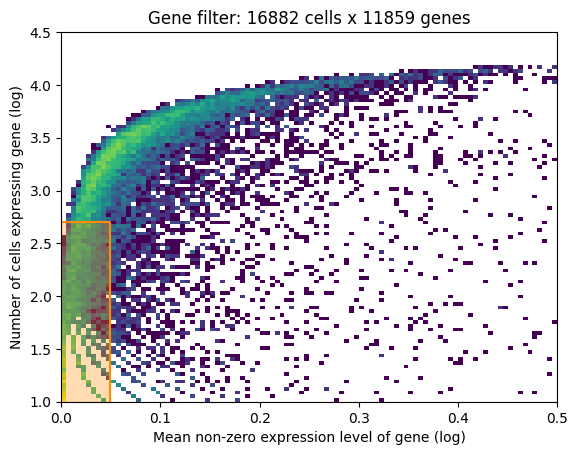

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'cell',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 16882 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   8   │
│          n_vars          │ 11859 │
└──────────────────────────┴───────┘

...

Epoch 3000/3000: 100%|███████████████████████████| 3000/3000 [12:41:35<00:00, 14.64s/it, v_num=1, elbo_train=1.1e+8]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 3000/3000: 100%|███████████████████████████| 3000/3000 [12:41:35<00:00, 15.23s/it, v_num=1, elbo_train=1.1e+8]

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...



Sampling global variables, sample: 100%|██████████████████████████████████████████| 999/999 [03:37<00:00,  4.59it/s]


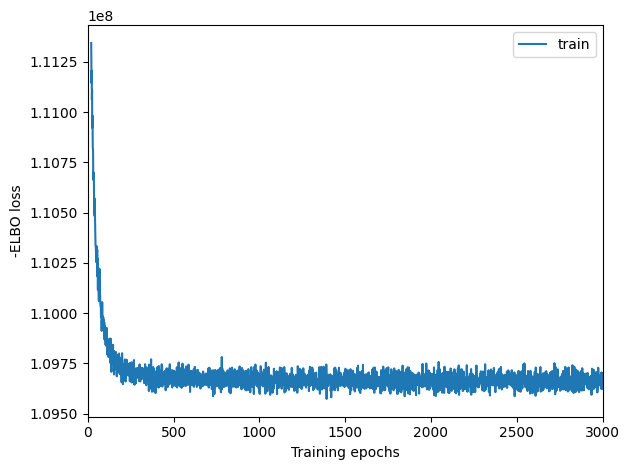

In [20]:
adata_file_bone_marrow = generate_cell2loc_signature(
    tissue_name="bone_marrow_20k",
    processed_sce_path='../intermediate_data/processed_sces/sequencing_depth/bone_marrow_20k_1_cell_ranger.h5ad',
    results_folder='../intermediate_data/cell2location_res/',
    n_epochs=3000,
)

In [ ]:
adata_file_glioma = generate_cell2loc_signature(
    tissue_name="glioma",
    processed_sce_path='../intermediate_data/processed_sces/glioma_sce.h5ad',
    results_folder='../intermediate_data/cell2location_res/',
    n_epochs=1000,
)